# Geração de Imagens e Treinamento Ângulo-Ordem (Order-CWT)

**Projeto:** Diagnóstico de Falhas em Rolamentos via CWT + Deep Learning  
**Metodologia:** Computed Order Tracking (COT) + Continuous Wavelet Transform  
**Objetivo:** Gerar escalogramas no domínio de ordens (amostras uniformes por volta do eixo) e treinar as arquiteturas convolucionais (`BearingCNN` e `ResNet-18`) com invariância à rotação (RPM).

---

## 1. Importação de Módulos e Configurações

In [2]:
import sys
from pathlib import Path

BASE_DIR = Path.cwd().parent.parent if Path.cwd().name == '4_order_tracking' else Path.cwd().parent
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

import torch
from src.config import (
    ORDER_CWRU_DIR,
    ORDER_PADERBORN_DIR,
    RANDOM_SEED,
    NUM_EPOCHS,
    LEARNING_RATE
)
from src.generate_order_dataset import generate_all_order_datasets
from src.transfer_learning import train_and_evaluate_transfer_model
from src.visualization import plot_training_curves, plot_confusion_matrix

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'[INFO] Dispositivo de treinamento: {device}')


[INFO] Dispositivo de treinamento: cuda


## 2. Geração Automática dos Escalogramas Ângulo-Ordem (Order-CWT)

Gera os datasets em `data/order_tracking/cwru/` e `data/order_tracking/paderborn/` sem Data Leakage.

In [3]:
# Executa o pipeline completo com normalização GLOBAL (Two-Pass + Z-Score)
generate_all_order_datasets(max_files_per_class=10)


[PIPELINE ORDER-CWT] Particionamento prévio estrito (Prevenção de Data Leakage)...
[Z-SCORE] Calculando estatísticas globais do CWRU (apenas partição de treino)...
    CWRU global (treino): mean=0.007085, std=0.267990 (3655099 amostras)
[Z-SCORE] Calculando estatísticas globais do Paderborn (apenas partição de treino)...
    Paderborn global (treino): mean=0.023454, std=0.230244 (5378772 amostras)
[PASS 1] Estimando vmin/vmax globais do CWRU Order-CWT (treino)...
    CWRU Order-CWT estimado: vmin=0.007656, vmax=1.693484
[PASS 1] Estimando vmin/vmax globais do Paderborn Order-CWT (treino)...
    Paderborn Order-CWT estimado: vmin=0.015321, vmax=2.706098
[Z-SCORE] Calculando estatísticas globais do XJTU-SY (apenas partição de treino)...
    XJTU-SY global (treino): mean=-0.006139, std=3.025506 (2064384 amostras)
[PASS 1] Estimando vmin/vmax globais do XJTU-SY Order-CWT (treino)...
    XJTU-SY Order-CWT estimado: vmin=0.007273, vmax=2.658666

[GLOBAL COMPARTILHADO TRIPARTITE (TREINO)] vmi

## 3. Treinamento da ResNet-18 no Dataset CWRU Ângulo-Ordem

[INFO] EXPERIMENTO TRANSFER LEARNING: RESNET18 | Freeze=False | Épocas=10 | LR=5e-05
Época [01/10] | Treino Loss: 0.0894 - Acc: 97.31% | Val Loss: 0.0083 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 01/10.
Época [02/10] | Treino Loss: 0.0045 - Acc: 99.95% | Val Loss: 0.0017 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 02/10.
Época [03/10] | Treino Loss: 0.0056 - Acc: 99.91% | Val Loss: 0.0012 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 03/10.
Época [04/10] | Treino Loss: 0.0014 - Acc: 100.00% | Val Loss: 0.0008 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 04/10.
Época [05/10] | Treino Loss: 0.0018 - Acc: 99.95% | Val Loss: 0.0004 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 05/10.
Época [06/10] | Treino Loss: 0.0009 - Acc: 100.00% | Val Loss: 0.0005 - Acc: 100.00% 
Época [07/10] | Treino Loss: 0.0010 - Acc: 99.98% | Val Loss: 0.0004 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 07/10.
Época [08/10] | Treino Loss: 0.0055 

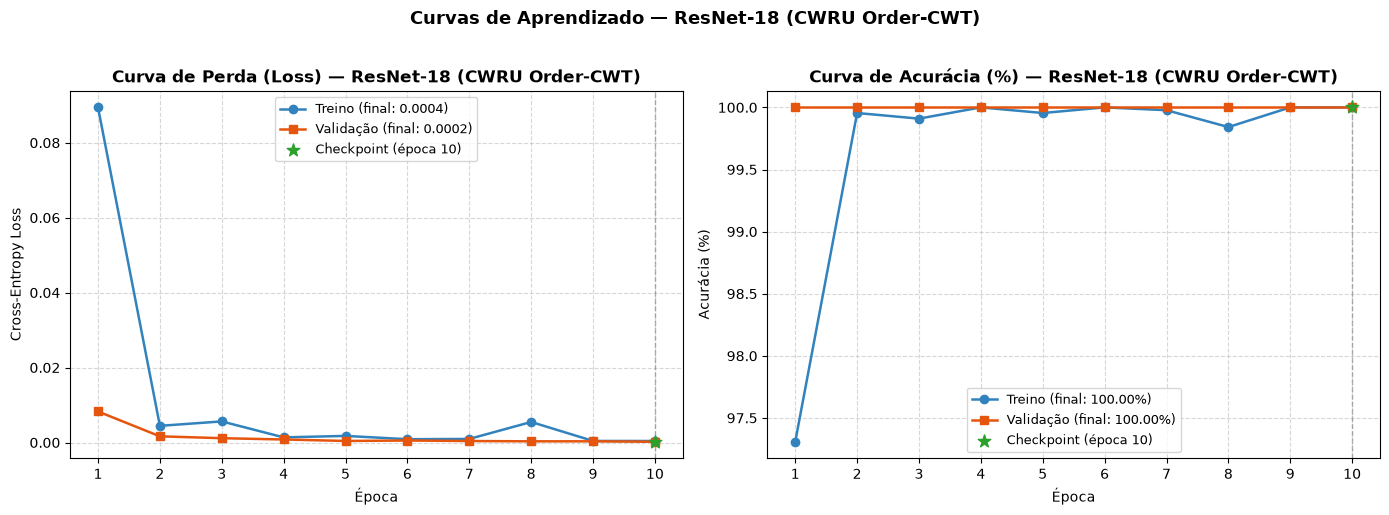

[INFO] Figura salva em: ../../docs/images/confusion_matrix_order_cwru_resnet.png


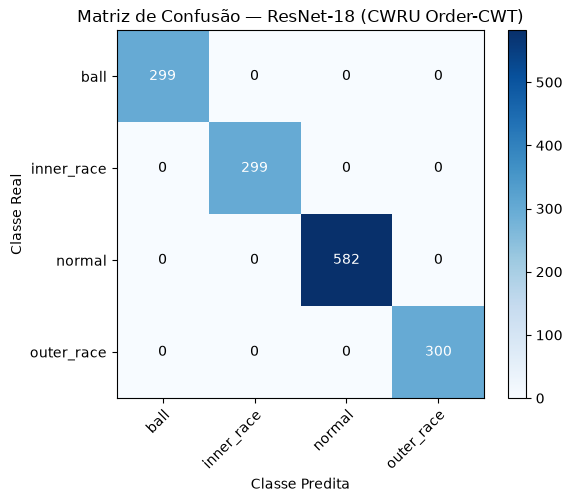

In [4]:
res_cwru_order = train_and_evaluate_transfer_model(
    model_name="resnet18",
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    freeze=False,
    data_dir=ORDER_CWRU_DIR,
    checkpoint_prefix="checkpoint_order_cwru"
)

plot_training_curves(
    res_cwru_order['history'],
    model_name="ResNet-18 (CWRU Order-CWT)",
    save_path="../../docs/images/training_curves_order_cwru_resnet.png"
)

plot_confusion_matrix(
    res_cwru_order,
    model_name="ResNet-18 (CWRU Order-CWT)",
    save_path="../../docs/images/confusion_matrix_order_cwru_resnet.png"
)

## 4. Treinamento da ResNet-18 no Dataset Paderborn Ângulo-Ordem

[INFO] EXPERIMENTO TRANSFER LEARNING: RESNET18 | Freeze=False | Épocas=10 | LR=5e-05
Época [01/10] | Treino Loss: 0.5326 - Acc: 74.55% | Val Loss: 0.2763 - Acc: 91.95% [CHECKPOINT] Modelo ótimo salvo na época 01/10.
Época [02/10] | Treino Loss: 0.1131 - Acc: 97.54% | Val Loss: 0.2524 - Acc: 91.95% [CHECKPOINT] Modelo ótimo salvo na época 02/10.
Época [03/10] | Treino Loss: 0.0393 - Acc: 98.85% | Val Loss: 0.1457 - Acc: 95.40% [CHECKPOINT] Modelo ótimo salvo na época 03/10.
Época [04/10] | Treino Loss: 0.0291 - Acc: 99.51% | Val Loss: 0.0725 - Acc: 96.55% [CHECKPOINT] Modelo ótimo salvo na época 04/10.
Época [05/10] | Treino Loss: 0.0152 - Acc: 99.84% | Val Loss: 0.2088 - Acc: 93.10% 
Época [06/10] | Treino Loss: 0.0088 - Acc: 100.00% | Val Loss: 0.0854 - Acc: 97.70% 
Época [07/10] | Treino Loss: 0.0139 - Acc: 99.67% | Val Loss: 0.0888 - Acc: 97.70% 
Época [08/10] | Treino Loss: 0.0123 - Acc: 99.84% | Val Loss: 0.0763 - Acc: 96.55% 
Época [09/10] | Treino Loss: 0.0089 - Acc: 99.84% | Va

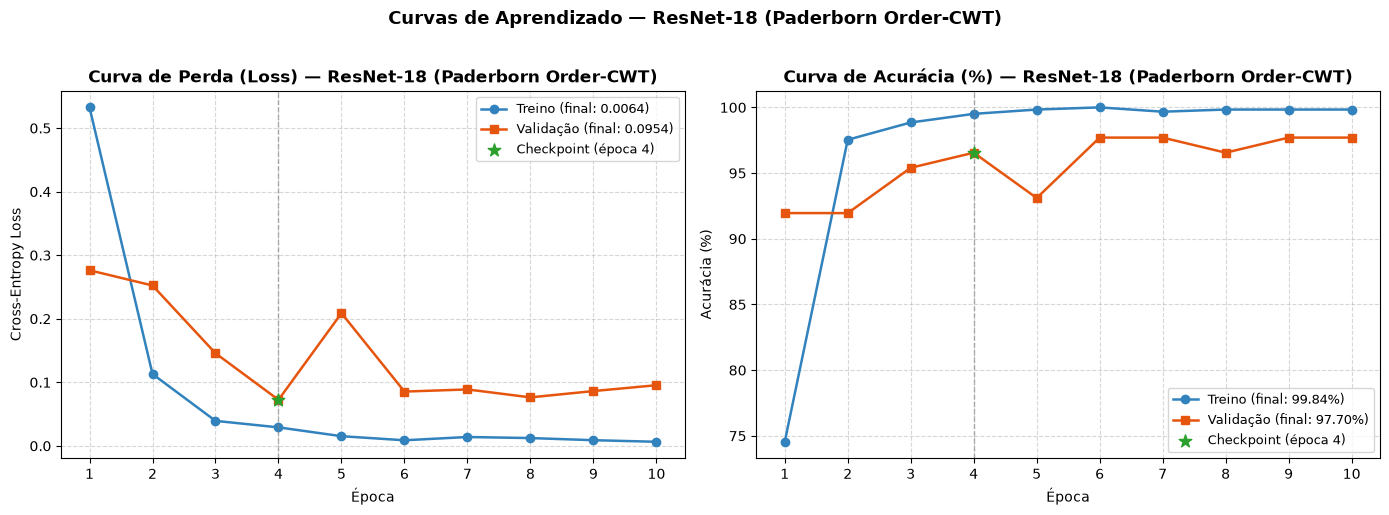

[INFO] Figura salva em: ../../docs/images/confusion_matrix_order_paderborn_resnet.png


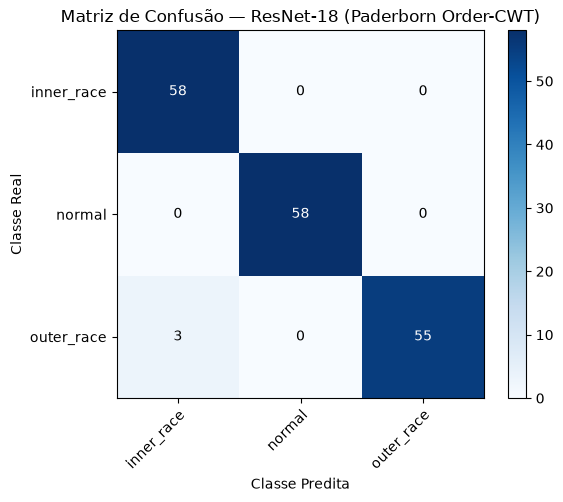

In [5]:
res_pad_order = train_and_evaluate_transfer_model(
    model_name="resnet18",
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    freeze=False,
    data_dir=ORDER_PADERBORN_DIR,
    checkpoint_prefix="checkpoint_order_paderborn"
)

plot_training_curves(
    res_pad_order['history'],
    model_name="ResNet-18 (Paderborn Order-CWT)",
    save_path="../../docs/images/training_curves_order_paderborn_resnet.png"
)

plot_confusion_matrix(
    res_pad_order,
    model_name="ResNet-18 (Paderborn Order-CWT)",
    save_path="../../docs/images/confusion_matrix_order_paderborn_resnet.png"
)

## 5. Geração dos Escalogramas Ângulo-Ordem do Dataset XJTU-SY

Geração dos escalogramas de ordens para o dataset XJTU-SY utilizando a mesma normalização Z-score e os mesmos limites globais de colormap (`vmin=0.007111, vmax=2.688748`) calculados na Seção 2, garantindo comparabilidade invariante à velocidade.


In [6]:
from src.config import ORDER_XJTU_DIR
from src.generate_order_dataset import generate_xjtu_order_dataset, _compute_xjtu_global_signal_stats

# 1. Estatísticas globais do XJTU-SY
xjtu_mean, xjtu_std = _compute_xjtu_global_signal_stats(max_files_per_class=10)

# 2. Geração normalizada com os limites compartilhados (Passo 2)
generate_xjtu_order_dataset(
    global_mean=xjtu_mean,
    global_std=xjtu_std,
    global_vmin=0.007111,
    global_vmax=2.688748,
    max_files_per_class=30
)


[Z-SCORE] Calculando estatísticas globais do XJTU-SY (apenas partição de treino)...
    XJTU-SY global (treino): mean=-0.009751, std=2.329916 (983040 amostras)

 GERAÇÃO DO DATASET ÂNGULO-ORDEM (ORDER-CWT) — XJTU-SY [GLOBAL NORM]
    1024 amostras/volta | Janela: 4 voltas | Ordens: 0.5-15.0
    Z-Score: mean=-0.0098, std=2.3299
    Colormap Norm: vmin=0.007111, vmax=2.688748
    ✅ XJTU-SY     normal (train): 21 arquivos -> 441 imagens geradas
    ✅ XJTU-SY     normal (  val): 4 arquivos -> 84 imagens geradas
    ✅ XJTU-SY     normal ( test): 5 arquivos -> 105 imagens geradas
    ✅ XJTU-SY inner_race (train): 21 arquivos -> 483 imagens geradas
    ✅ XJTU-SY inner_race (  val): 4 arquivos -> 92 imagens geradas
    ✅ XJTU-SY inner_race ( test): 5 arquivos -> 115 imagens geradas
    ✅ XJTU-SY outer_race (train): 21 arquivos -> 441 imagens geradas
    ✅ XJTU-SY outer_race (  val): 4 arquivos -> 84 imagens geradas
    ✅ XJTU-SY outer_race ( test): 5 arquivos -> 105 imagens geradas

[+] Total

## 6. Treinamento da ResNet-18 no Dataset XJTU-SY Ângulo-Ordem

Treinamento com Fine-Tuning da ResNet-18 sobre os escalogramas de ordens gerados para o XJTU-SY. O checkpoint com o menor `val_loss` será salvo em `checkpoint_order_xjtu_resnet18_best.pth`.


[INFO] EXPERIMENTO TRANSFER LEARNING: RESNET18 | Freeze=False | Épocas=10 | LR=5e-05
Época [01/10] | Treino Loss: 0.0991 - Acc: 96.70% | Val Loss: 0.0012 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 01/10.
Época [02/10] | Treino Loss: 0.0024 - Acc: 100.00% | Val Loss: 0.0007 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 02/10.
Época [03/10] | Treino Loss: 0.0018 - Acc: 100.00% | Val Loss: 0.0004 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 03/10.
Época [04/10] | Treino Loss: 0.0011 - Acc: 100.00% | Val Loss: 0.0003 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 04/10.
Época [05/10] | Treino Loss: 0.0011 - Acc: 100.00% | Val Loss: 0.0002 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 05/10.
Época [06/10] | Treino Loss: 0.0007 - Acc: 100.00% | Val Loss: 0.0002 - Acc: 100.00% 
Época [07/10] | Treino Loss: 0.0010 - Acc: 100.00% | Val Loss: 0.0001 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 07/10.
Época [08/10] | Treino Loss: 0.0

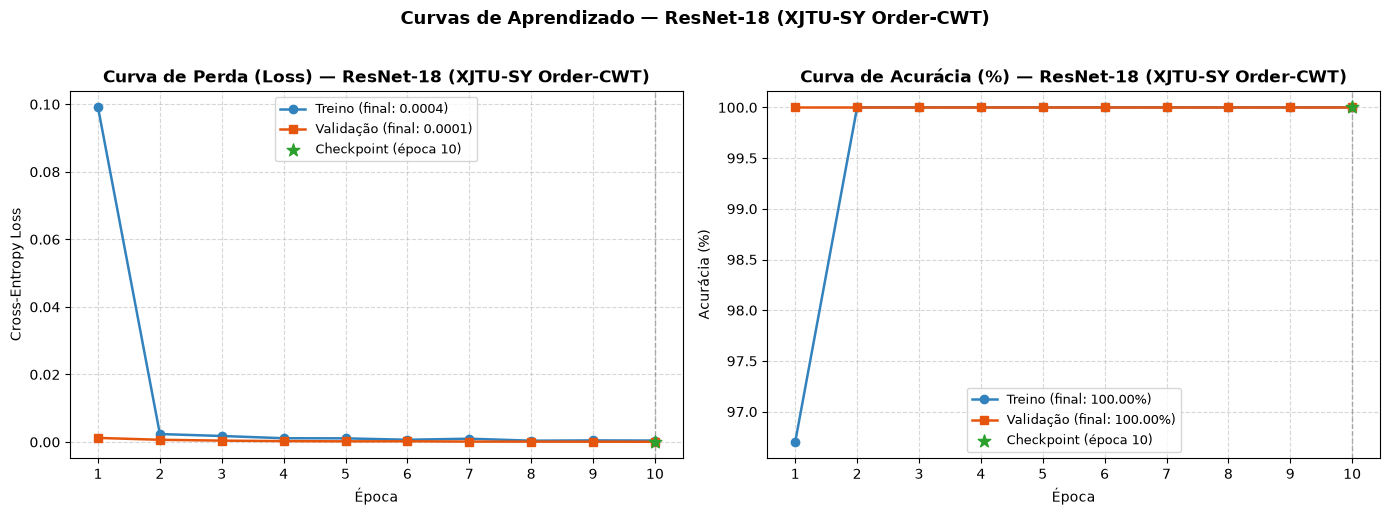

[INFO] Figura salva em: ../../docs/images/confusion_matrix_order_xjtu_resnet.png


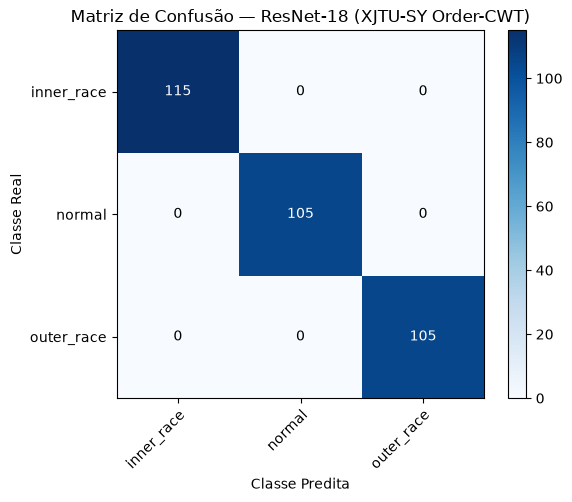

In [7]:
res_xjtu_order = train_and_evaluate_transfer_model(
    model_name="resnet18",
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    freeze=False,
    data_dir=ORDER_XJTU_DIR,
    checkpoint_prefix="checkpoint_order_xjtu"
)

plot_training_curves(
    res_xjtu_order['history'],
    model_name="ResNet-18 (XJTU-SY Order-CWT)",
    save_path="../../docs/images/training_curves_order_xjtu_resnet.png"
)

plot_confusion_matrix(
    res_xjtu_order,
    model_name="ResNet-18 (XJTU-SY Order-CWT)",
    save_path="../../docs/images/confusion_matrix_order_xjtu_resnet.png"
)
